##### **Multi-Model (Image Data) Breast Cancer Diagnosis Prediction**

###### **Meritshot Intenship**

This project aims to **build a machine learning model that predicts whether a breast tumor is malignant (cancerous) or benign (non-cancerous)**. Early detection is important because it improves treatment outcomes. What's makes this good is that ML models can potentially analyze patterns accross mulitple features simultanously, potentially catching patterns humans can miss. The **goal is to develop a reliable prediction system using image data and  then clinical features**. The project workflow is as follows:
1. Problem Statement
2. Dataset Description
3. Data Loading
4. Data Overview
5. Data Preprocessing
6. Model Building
7. Data Augmentation
8. Model Training
9. Model Evaluation
10. Prediction
11. Insights & Conclusion

###### **1. Problem Statement**

Breast cancer is one of the most common cancers in the world, and detecting it early can save or prolong lives. While doctors typically rely on lab results and imaging tests to determine whether a tumor is cancerous, analyzing large numbers of histopathology images manually can be time-consuming and prone to error.

In this project, the goal is simple: **build a machine learning model that can predict whether a tumor is malignant (cancerous) or benign (non-cancerous) using histopathology image data.**
Later, this system will be enhanced by **combining cell nuclei morphological features with image data**, simulating how real hospital systems integrate multiple sources of information to support more accurate diagnosis.

**The aim is to explore how data-driven methods can support early diagnosis and assist clinical decision-making.**

###### **2. Dataset Description**

The dataset used in this project is the BreakHis histopathology image dataset, gotten from [BreakHis dataset Kaggle](https://www.kaggle.com/datasets/waseemalastal/breakhis-breast-cancer-histopathological-dataset), which contains breast tumor tissue images collected from real patient samples. Histopathology is the standard method for diagnosing breast cancer, as it allows doctors to examine the cellular structure of tissue and determine whether a tumor is **benign or malignant**. For this project, we focus on the **40X magnification images**, which provide sufficient detail for a **convolutional neural network** to learn meaningful patterns while keeping the dataset manageable.

This dataset includes digitalized images from both **benign (0) and malignant (1) tumors**, covering multiple subtypes, but for the purposes of this project, we treat it as a **binary classification problem**. Organizing the images into ‘benign’ and ‘malignant’ folders allows the CNN to efficiently process the data and learn to distinguish between the two classes. Using real patient samples makes this dataset clinically relevant and ensures that the model learns patterns that matter in real-world diagnosis.

###### **3. Data Loading**

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import os
import zipfile

zip_path = "/content/binary.zip"
extract_path = "/content/breakhis_40X"

# extraction
os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# checking folder structure
data_path = os.path.join(extract_path, "binary")
print(os.listdir(data_path))

['malignant', 'benign']


###### **4. Data Overview**

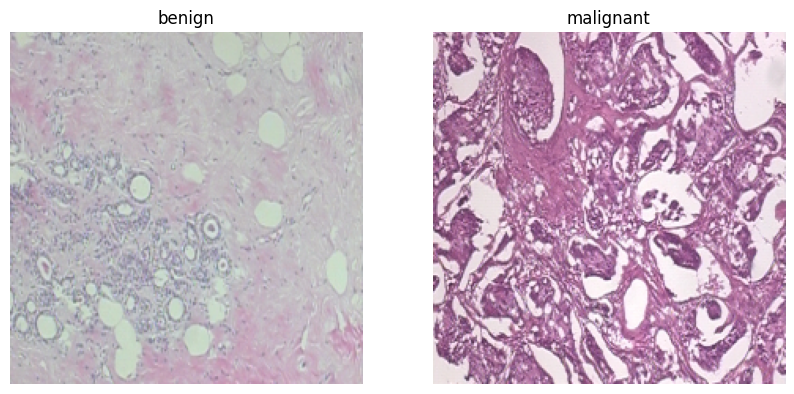

benign: 625 images
malignant: 1370 images


In [ ]:
import matplotlib.pyplot as plt
import random
import matplotlib.image as mpimg

classes = ["benign", "malignant"]

# showing 1 image per class
plt.figure(figsize=(10, 5))
for idx, cls in enumerate(classes):
    cls_folder = os.path.join(data_path, cls)
    image_file = random.choice(os.listdir(cls_folder))
    img = mpimg.imread(os.path.join(cls_folder, image_file))
    plt.subplot(1, 2, idx+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
plt.show()

# counting images per class
for cls in classes:
    print(f"{cls}: {len(os.listdir(os.path.join(data_path, cls)))} images")

###### **5. Data Preprocessing**

In [ ]:
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

IMG_SIZE = 50  # resize all images
X = []         # features (the images)
y = []         # labels (the tissue types)

for idx, cls in enumerate(classes):
    cls_folder = os.path.join(data_path, cls)
    for img_file in os.listdir(cls_folder):
        img_path = os.path.join(cls_folder, img_file)
        img = cv2.imread(img_path)                       # load image as numbers
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))      # resize to 50x50
        X.append(img)                                    # image pixels (numbers)
        y.append(idx)                                    # label (0 or 1)

In [ ]:
# converting to NumPy Arrays
import numpy as np
X = np.array(X)
y = np.array(y)

In [ ]:
# normalization(feature scaling: MinMaxScaler manually)
X = X / 255.0  # normalize the image pixel values to be between 0 and 1
# spliting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1596, 50, 50, 3) (1596,)
(399, 50, 50, 3) (399,)


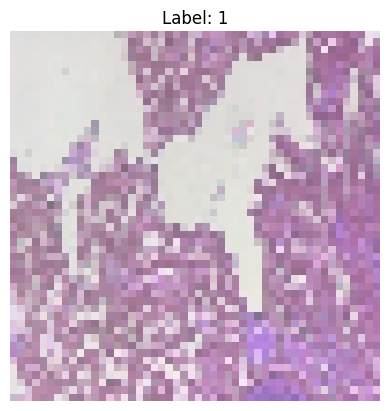

In [ ]:
# visualizing using matplotlib
plt.imshow(X_train[0])             # displays the image visually
plt.title(f"Label: {y_train[0]}")  # y_train to show the image
plt.axis('off')
plt.show()

###### **6. Model Building**

In [ ]:
# definition and building the CNN Model
model = Sequential()

# 1st convolutional block to detect basic features
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(50, 50, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# 2nd convolutional block to detect deeper features
model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(50, 50, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# 3rd convolutional block for deeper insights
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))


# global average pooling(lightweight)
model.add(GlobalAveragePooling2D())


# dense layers
model.add(Dropout(0.25))  # to reduce overfitting
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.25))  # to reduce overfitting
model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# compiling the CNN Model to decide how it learn
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)              │ (None, 50, 50, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 50, 50, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 25, 25, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

###### **7. Data Augmentation**

In [ ]:
# augmentation (feeding images into the CNN Model using ImageDataGenerator)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
# learning from training data
train_generator = train_datagen.flow(X_train, y_train, batch_size=32)
val_generator = val_datagen.flow(X_test, y_test, batch_size=32)

###### **8. Model Training**

In [ ]:
# training the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=14
)

Epoch 1/14
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 394ms/step - accuracy: 0.7830 - loss: 0.4655 - val_accuracy: 0.6867 - val_loss: 0.8711
Epoch 2/14
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 287ms/step - accuracy: 0.8078 - loss: 0.4581 - val_accuracy: 0.6867 - val_loss: 1.2792
Epoch 3/14
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 281ms/step - accuracy: 0.8226 - loss: 0.4261 - val_accuracy: 0.6867 - val_loss: 1.7769
Epoch 4/14
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 286ms/step - accuracy: 0.8350 - loss: 0.3756 - val_accuracy: 0.6867 - val_loss: 1.8830
Epoch 5/14
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 287ms/step - accuracy: 0.8417 - loss: 0.3835 - val_accuracy: 0.6867 - val_loss: 1.4744
Epoch 6/14
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 288ms/step - accuracy: 0.8330 - loss: 0.3787 - val_accuracy: 0.6867 - val_loss: 2.0010
Epoch 7/14
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 286ms/step - accuracy: 0.8536 - loss: 0.3540 - val_accuracy: 0.6892 - val_loss: 1.9683
Epoch 8/14
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 273ms/step - accuracy: 0.8453 - loss: 0.3491 - val_accu

###### **9. Model Evaluation**

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8418 - loss: 0.3834
Test Accuracy: 84.21 %
Test Loss: 0.4008
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


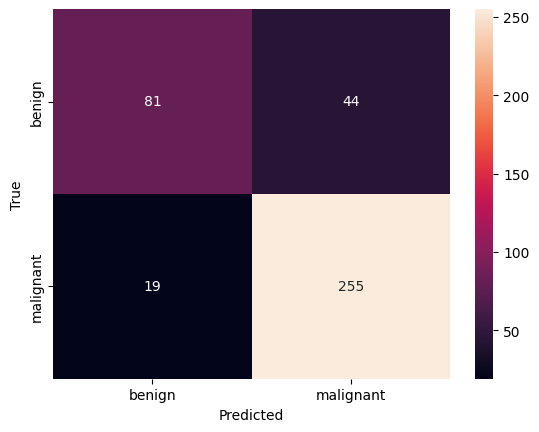

              precision    recall  f1-score   support

      benign       0.81      0.65      0.72       125
   malignant       0.85      0.93      0.89       274

    accuracy                           0.84       399
   macro avg       0.83      0.79      0.81       399
weighted avg       0.84      0.84      0.84       399



In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# evaluation on test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", round(test_acc*100,2), "%")
print("Test Loss:", round(test_loss,4))

# predictions (sigmoid output)
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int).reshape(-1)  # convert probabilities to 0 or 1
y_true = y_test  # y_test is already 0 or 1

# confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# classification Report
print(classification_report(y_true, y_pred, target_names=classes))

###### **10. Prediction**

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step


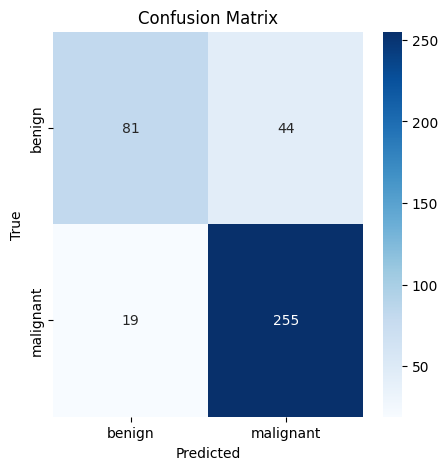

              precision    recall  f1-score   support

      benign       0.81      0.65      0.72       125
   malignant       0.85      0.93      0.89       274

    accuracy                           0.84       399
   macro avg       0.83      0.79      0.81       399
weighted avg       0.84      0.84      0.84       399



In [ ]:
# Predict probabilities
y_pred_probs = model.predict(X_test)

# Convert probabilities to binary labels (0 or 1)
y_pred = (y_pred_probs > 0.5).astype(int).reshape(-1)

# True labels (already 0 or 1)
y_true = y_test

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_true, y_pred, target_names=classes))

In [ ]:
# saving the model
model.save("breast_cancer_binary_model.h5")

In [ ]:
# loading the model
from tensorflow.keras.models import load_model
model = load_model("breast_cancer_binary_model.h5")

In [ ]:
# predicting on new image
IMG_SIZE = 50

# loading image
img_path = "/content/breakhis_40X/binary/benign/SOB_B_PT-14-22704-40-035.png"
img = cv2.imread(img_path)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # resize to match training
img = img / 255.0  # normalize
img = np.expand_dims(img, axis=0)  # model expects a batch

# load the trained model
model = load_model("/content/breast_cancer_binary_model.h5")

# prediction
pred_probs = model.predict(img)
pred_class = np.argmax(pred_probs, axis=1)[0]  # 0 or 1

classes = ["benign", "malignant"]
print(f"Predicted class: {classes[pred_class]}")
print(f"Probabilities: {pred_probs}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
Predicted class: benign
Probabilities: [[0.02563302]]


###### **11. Insights and Conclusion**

**Insights**

* The CNN learned to tell benign from malignant breast tumor images pretty well. Training accuracy went up to ~87%, and validation ended around ~84%.
* Sometimes the model got a bit confused, especially in the early epochs, which shows it overfit a little on training data.
* Data augmentation (rotations, flips, zooms) helped the model generalize better.
* Preprocessing is important—training and prediction image sizes must match, otherwise OpenCV throws errors.
* The model works on new images, predicting the correct class and giving probability scores.

**Conclusion**

* The CNN can help detect breast cancer from images, supporting doctors and saving time.
* It’s not perfect more data, better tuning, and careful preprocessing can improve it.

Next, i'm making it a multi-modal by combining image features with clinical data (like characteristics of the nuclei) to get even more accurate predictions.